In [3]:
import sys
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm,Normalize, SymLogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
# sys.path.insert(0, '/home/yu/Programs/Athena/athena-df_20230314/vis/python')
sys.path.insert(0, '/home/izx/athena_sublimation/vis/python')
import athena_read
import re
import pickle
from snowline_head import *

In [4]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.weight": 'normal',
    "font.size": 15,
})

# plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rcParams['mathtext.fontset'] = 'cm'
# plt.rc('text.latex', preamble=r'\usepackage{mathptmx}')
plt.rc('text.latex', preamble=r'\usepackage{newtxtext,newtxmath}')
plt.rc('pgf', texsystem='pdflatex')  # Use pdflatex instead of the default LaTeX engine

In [5]:
# import constants
from snowline_head import *

In [6]:
# disk slope
H_slope = 1.25 # Alarcon+ 2023
Cs_slope = H_slope - 1.5
qvalue = 2.0*Cs_slope
sigma_slope = -1 
nu_slope = -sigma_slope

pvalue = sigma_slope - H_slope # midplane gas density slope
# pvalue = -(qvalue + 1.5) - H_slope
p_slope = qvalue + pvalue # pressure

# disk parameter    
M_star = 1 # Msun
# M_disc = 0.57 # Msun
# L_star = (2.5)**2 * (7000/5778)**4 # L_sun
L_star = 1.0 # L_sun

# fitted by Cieza+ 2018
# R_c = 31.0 # AU
# sigma_c = M_disc*M_sun*(2.0 + sigma_slope)/(2.0*pi*(R_c*AU)**2)
a0 = 3.0 # R_c[AU], reference position of disk temperature/density profile
# H_profile = lambda r: 0.033*AU*(r/1.0)**(H_slope)
Omega_profile = lambda r: sqrt(GM_sun*M_star/(r*AU)**3)

# Cs0 = H_profile(a0)*Omega_profile(a0)
# T0 = Cs0**2/(k_B/(2.34*m_p))
T0 = 150
T_profile = lambda r: T0*(r/3.0)**(qvalue)
Cs0 = sqrt(k_B*T0/(2.34*m_p))

# default value
Mdot_gas = 1e-8*M_sun/YR
alpha = 0.003
# UNIT_T = 1.0/Omega_profile(a0) # 1/omega at planet position
UNIT_T = 26097389.234
Sigma0 = Mdot_gas/(3.0*pi*alpha*Cs0**2*UNIT_T) # gas surface density at planet position
sigma_profile = lambda r: Sigma0*(r/a0)**(sigma_slope)

print("pvalue=",pvalue)
print("qvalue=",qvalue)
print("nu_slope=",nu_slope)
# print("sigma_c =",sigma_c)
print("UNIT_T =",UNIT_T)
print("sigma0 =",Sigma0)
print("L_star=",L_star)
print("T0=",T0)
print(Cs0)

pvalue= -2.25
qvalue= -0.5
nu_slope= 1
UNIT_T = 26097389.234
sigma0 = 161.38401528135645
L_star= 1.0
T0= 150
72741.19806091097


In [7]:
# non-dimensional units
UNIT_V = Cs0
UNIT_L = 1898355359100.0  # scale height at reference poistion
UNIT_DEN = Sigma0/(sqrt(2*pi)*UNIT_L)
UNIT_ERG = UNIT_DEN*UNIT_L**3*UNIT_V**2
UNIT_FLX = UNIT_ERG/(UNIT_L**2*UNIT_T)
UNIT_PRS = UNIT_DEN*UNIT_V**2
kB_mp = k_B/m_p/(UNIT_V**2)
KELVIN = 1.0/kB_mp

mu_xy = 2.34
mu_z = chem_H2O.mu
P_eq0 = chem_H2O.P_eq/UNIT_PRS
L_heat = chem_H2O.L_heat/UNIT_V**2
T_a = chem_H2O.T_a

print(UNIT_L)

1898355359100.0


In [8]:
para_define = {'a_semi':a0, 'UNIT_VELOCITY':UNIT_V, 'UNIT_T':UNIT_T, 'UNIT_LENGTH':UNIT_L, 'UNIT_DENSITY':UNIT_DEN, 'KELVIN': 1.0/kB_mp, 'mu_z':mu_z,
 'L_heat':L_heat, 'T_a':T_a, 'P_eq0':P_eq0}

In [9]:
# # write into WKDIR+"/athinput.disk_cyl_SMR", all code unit'
# WKDIR = '/home/yu/Programs/Athena/athena-df_20230314/src/'
# f = open(WKDIR+'defs.hpp.in','r+')
# s = f.read()
# new_f = ''

# for key in para_define:
#     p1 = r'\n(#define\s*'+key+'\s+\S+)'
#     repl = re.findall(p1,s)[0]
    
#     s = s.replace(repl,'{0:<40}{1:.10e}'.format('#define  '+key, para_define[key]))
#     print(repl)

# f.seek(0,0)
# f.write(s)
# f.close()

In [10]:
# dimensionless quantity used in intial set-up.
r0 = a0*AU/UNIT_L
GM = (r0)**3
L_norm = AU/UNIT_L

tau_vis = a0*AU**2/(alpha*Cs0**2*UNIT_T) / (YR) # in yr
tlim = 10*tau_vis*YR/UNIT_T
dt = 0.01*tau_vis*YR/UNIT_T

x1min = 0.3*AU/UNIT_L
x1max = 3*AU/UNIT_L

# H_max = 8.0*H_profile(a0)/AU # au
theta_upper = 1.30

x2min = theta_upper
x2max = pi/2
print(x2min)
print(x2min+ (x2max-x1min)*0.4)

1.3
0.9826713209926506


In [11]:
print('x1min =',x1min)
print('x1max =',x1max)
print('GM =',GM)
print('theta_upper =',theta_upper)
print("UNIT_V=",UNIT_V)
print("UNIT_L=",UNIT_L)
print("UNIT_DEN=",UNIT_DEN)
print("KELVIN=",1/kB_mp)
print("L_heat=",L_heat)
print("P_eq0=",P_eq0)
print("tlim=",tlim)
print("dt=",dt)
print("r0 =", r0)
print("T0 = ",T0)

x1min = 2.36411802431327
x1max = 23.6411802431327
GM = 13213.183377999183
theta_upper = 1.3
UNIT_V= 72741.19806091097
UNIT_L= 1898355359100.0
UNIT_DEN= 3.391509749112916e-11
KELVIN= 64.10256410256412
L_heat= 5.197228298162747
P_eq0= 63525908124011.83
tlim= 621006.0036254679
dt= 621.006003625468
r0 = 23.6411802431327
T0 =  150


In [12]:
# estimate alpha at a0:
# alpha_a0 = Mdot_gas/(3.0*pi*sigma_c) / (Cs0**2*UNIT_T)
# print("alpha_estimate = ",alpha_a0)
print("$\\tau_{vis}$" +'~ %.2f Yr'%(tau_vis))

$\tau_{vis}$~ 51356.78 Yr


In [13]:
nr = 400
ntheta = 150
rho = zeros((nr,ntheta))
T = zeros((nr,ntheta))

theta, r = meshgrid(linspace(x2min,x2max,ntheta), logspace(log10(x1min),log10(x1max),nr))

In [14]:
def DenProfile(r, z, Tem):
    mu = 2.34
    cs2 = Tem/(KELVIN*mu)
    H_gas = sqrt(cs2) / sqrt(GM / r**3)
    denmid = 1.0* (r/r0)**(sigma_slope) / H_gas
    dentem = denmid * exp(GM/cs2*(1/ sqrt(r**2 + z**2) - 1/r))
    
    return dentem

def f_nu_gas(r, theta, r0):
    x = r * sin(theta) / L_norm
    z = r * cos(theta) / L_norm
    
    tmp = alpha*(x/(r0/L_norm))**(-sigma_slope)
    
    f_x = 1.0
    
    tmp *= f_x
    
    return  tmp

def f_nu_gas_GI(r, theta, Q, cs, Omega):
    # Zhu et al 2009b
    alpha_Q = exp(-Q**2)
    
    return alpha_Q*(cs**2/Omega) * sin(theta)**(3/2)

def f_nu_gas_pres(r, theta,r0):
    x = r * sin(theta) / L_norm
    z = r * cos(theta) / L_norm
    
    tmp = (x/(r0/L_norm))**(-sigma_slope)
    
    f_x = (1e2*alpha - alpha) *tanh(((3-x)/(0.5)))+ alpha
    f_x[f_x<alpha] = alpha
    
    tmp *= f_x
    
    return  tmp


In [15]:
L_star_array = logspace(log10(0.03),log10(1),50)
kappa_R_array = logspace(-3,-2,200)
f_vi_array = 10.0 / kappa_R_array
# L_star_array = array([1.0])
# kappa_R_array = array([0.55]) * UNIT_DEN *UNIT_L
r_snow_array = zeros((len(L_star_array),len(kappa_R_array)))
T_r0_array = zeros((len(L_star_array),len(kappa_R_array)))

In [16]:
# ice flux ratio:
f_vapor = 0.4

rad = r[:,-1] / L_norm
# index
index_r0 = rad[rad <= 2.1*rad[0]].shape[0]
print("index_r0 = ",index_r0)
print(rad)

index_r0 =  129
[0.3        0.30173627 0.30348259 0.30523902 0.30700561 0.30878243
 0.31056953 0.31236698 0.31417482 0.31599313 0.31782197 0.31966139
 0.32151145 0.32337222 0.32524376 0.32712613 0.3290194  0.33092362
 0.33283887 0.3347652  0.33670268 0.33865137 0.34061134 0.34258265
 0.34456537 0.34655957 0.34856531 0.35058266 0.35261168 0.35465245
 0.35670502 0.35876948 0.36084588 0.36293431 0.36503482 0.36714748
 0.36927237 0.37140957 0.37355913 0.37572113 0.37789564 0.38008274
 0.3822825  0.38449498 0.38672028 0.38895845 0.39120957 0.39347373
 0.39575099 0.39804142 0.40034512 0.40266215 0.40499258 0.40733651
 0.409694   0.41206513 0.41444999 0.41684865 0.41926119 0.4216877
 0.42412824 0.42658292 0.4290518  0.43153497 0.43403251 0.4365445
 0.43907104 0.44161219 0.44416805 0.44673871 0.44932424 0.45192474
 0.45454029 0.45717097 0.45981688 0.46247811 0.46515473 0.46784685
 0.47055455 0.47327792 0.47601705 0.47877203 0.48154296 0.48432993
 0.48713302 0.48995234 0.49278798 0.49564002 0.4

In [17]:
for j in range(1):
    for i in range(1):
        # print(i,j)
        L_star = 5
        kappa_R = 0.01*UNIT_DEN*UNIT_L
        # f_vi = f_vi_array[i]/(UNIT_DEN*UNIT_L)
        f_vi = 10.0*UNIT_DEN*UNIT_L/ (kappa_R) # kappa_vi = 10.0
        f_vi=2.5
        # print(f_vi)


        # initial density
        z = r*cos(theta)
        Tem = T0*(r/r0)**qvalue
        rho0 = DenProfile(r, z, Tem)

        rho = rho0
        dx2 = abs(theta[0,0] - theta[0,1])*r

        # optical depth
        dkapparho = dx2*rho*kappa_R
        tau_vi = array([sum(dkapparho[:,:i],axis = 1) for i in range(ntheta)]).T

        H_gas0 = (r/r0)**(qvalue/2.0 + 1.5)
        cos_inc = (qvalue/2.0 + 0.5) * (4.0*H_gas0/r)

        # heating

        tau_inf = array([tau_vi[:,-1]* 2.0]* ntheta).T
        E0 = L_star * L_sun / (UNIT_ERG/UNIT_T) / (8.0*pi*r**2)
        q_irr = E0 * f_vi * rho *  kappa_R * (exp(-f_vi * tau_vi/cos_inc) + exp(-f_vi * (tau_inf - tau_vi)/cos_inc))

        nu_gas = alpha*(r/r0)**(-sigma_slope)
        # nu_gas = f_nu_gas(r, theta, r0)
        omega = sqrt(GM/r**3)
        q_vis = 9.0/4.0* rho*nu_gas * omega**2

        # q_int
        q_z = q_irr + q_vis
        dq_int = q_z*dx2
        q_int = array([sum(dq_int[:,:i],axis = 1) for i in range(ntheta)]).T

        # tau_eff
        F_inf = array([q_int[:,-1]]*ntheta).T
        dtau_eff = rho * kappa_R * (1.0 - q_int/F_inf) * dx2
        tau_eff = array([sum(dtau_eff[:,:i],axis = 1) for i in range(ntheta)]).T

        # Get temperature
        T_eff = (F_inf/(sigma_sb/UNIT_FLX))**(0.25)
        Tem = 0.75*tau_eff + sqrt(3.0)/4.0 + q_z / (4.0*rho*kappa_R*F_inf)
        Tem = Tem**(0.25)*T_eff

        
        # get_snowline
        
        Tem_mid = Tem[:,-1]
        P_eq = P_eq0*exp(-T_a/Tem_mid)
        rho_mid = f_vapor * (rho[:,-1])
        P_mid = rho_mid * kB_mp * Tem_mid / mu_water
        rad = r[:,-1] / L_norm
        tmp = rad[where(P_eq/P_mid > 1.0)]
        if(len(tmp) > 0):
            r_snow = tmp[-1]
        else:
            r_snow = 0.0
        
        r_snow_array[j,i] = r_snow
        T_r0_array[j,i] = Tem_mid[index_r0]
        print ("L_star = %.3f, kappa_R = %.3e, r_snow = %.3f, T_r0 = %.2f"%(L_star,kappa_R,r_snow,Tem_mid[index_r0]))
        print(f_vi)

L_star = 5.000, kappa_R = 6.438e-01, r_snow = 0.858, T_r0 = 223.78
2.5


In [2]:
fig = plt.figure(figsize=(6,6), facecolor='w')
ax = fig.add_subplot(111)
aax = ax.contourf(L_star_array, kappa_R_array , r_snow_array.T, levels = linspace(1,4,100), cmap='coolwarm', extend = 'both')
ax.contour(L_star_array, kappa_R_array , r_snow_array.T,levels = [1.0], colors = 'k', linewidths = 2)
ax.contour(L_star_array, kappa_R_array, r_snow_array.T,levels = [2.1], colors = 'k', linewidths = 2)
ax.scatter(22, 0.01, color = 'k', s = 100, marker = '*', label = 'simulation point')

ax.contour(L_star_array, kappa_R_array, T_r0_array.T,levels = linspace(100,200,11), colors = 'k', linewidths = 0.7, linestyles = '--')
divider = make_axes_locatable(ax)
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0 + 0.05,0.03,ax.get_position().height/1.2])
cl1 = fig.colorbar(aax,cax = cax)
cl1.minorticks_on()
cl1.set_label('$r_{\mathrm{snow,mid}}$ [au]',fontsize = 15)
cl1.set_ticks([1.0,2.0,3.0,4.0])

ax.set_xlim(0.03,50)
ax.set_ylim(1e-5,10)

# simulation point
# ax.scatter(1.0,4.0,color = 'k',s = 100)
# ax.scatter(21.0,0.01,color = 'k',s = 100)
# ax.scatter(1.0,1.2e-5,color = 'k',s = 100)

# separation line
# c1 = [1.0,1.e-2]
# e1 = [50,1.e-5]
# e2 = [50,10]
# e3 = [0.03,1.e-2]

# ax.plot([c1[0],e1[0]],[c1[1],e1[1]],'w--')
# ax.plot([c1[0],e2[0]],[c1[1],e2[1]],'w--')
# ax.plot([c1[0],e3[0]],[c1[1],e3[1]],'w--')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$L_{\star} (L_{\odot})$',fontsize = 15)
ax.set_ylabel('$\kappa_R$ [cm$^2$ g$^{-1}$]',fontsize = 15)

# ax.annotate('active disk', xy=(0.4, 0.85), xycoords='axes fraction', fontsize = 18, color='w')
ax.annotate('2.1 au', xy=(0.7, 0.5), xycoords='axes fraction', fontsize = 18, color='k')
ax.annotate('1 au', xy=(0.5, 0.5), xycoords='axes fraction', fontsize = 18, color='k')
# ax.annotate('100 K', xy=(0.4, 0.6), xycoords='axes fraction', fontsize = 15, color='k')
# ax.annotate('200 K', xy=(0.85, 0.92), xycoords='axes fraction', fontsize = 15, color='k')
# ax.annotate('passive disk', xy=(0.6, 0.5), xycoords='axes fraction', fontsize = 18, color='w')
# ax.annotate('vertically-isothermal', xy=(0.3, 0.12), xycoords='axes fraction', fontsize = 18, color='w')

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\k'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_3716279/1499571685.py:13: SyntaxWarning: invalid escape sequence '\m'
  cl1.set_label('$r_{\mathrm{snow,mid}}$ [au]',fontsize = 15)
/tmp/ipykernel_3716279/1499571685.py:36: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel('$L_{\star} (L_{\odot})$',fontsize = 15)
/tmp/ipykernel_3716279/1499571685.py:37: SyntaxWarning: invalid escape sequence '\k'
  ax.set_ylabel('$\kappa_R$ [cm$^2$ g$^{-1}$]',fontsize = 15)
/tmp/ipykernel_3716279/1499571685.py:13: SyntaxWarning: invalid escape sequence '\m'
  cl1.set_label('$r_{\mathrm{snow,mid}}$ [au]',fontsize = 15)
/tmp/ipykernel_3716279/1499571685.py:36: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel('$L_{\star

NameError: name 'plt' is not defined

In [ ]:
#get the snowline location 
L_idx = argmin(abs(L_star_array - 1.0))
kR_idx = argmin(abs(kappa_R_array - 0.01))
r_snow = r_snow_array[L_idx,kR_idx]
print(r_snow)

0.0


/tmp/ipykernel_3707860/2396582948.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax0 =  ax.pcolormesh(x_c,y_c,Tem,norm = Normalize(vmin = 100,vmax = 500,clip = True) ,cmap = 'coolwarm', alpha = 1)


Text(0, 0.5, '$y$ [au]')

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

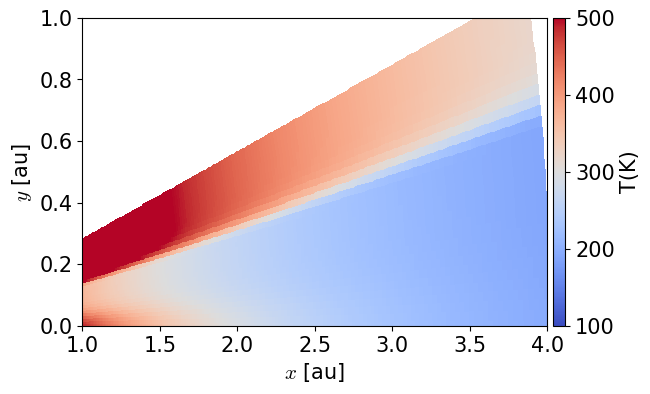

In [150]:
x_c = r*sin(theta) / L_norm
y_c = r*cos(theta) / L_norm

fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax0 =  ax.pcolormesh(x_c,y_c,Tem,norm = Normalize(vmin = 100,vmax = 500,clip = True) ,cmap = 'coolwarm', alpha = 1)

# C_Tem = ax.contour(x_c,y_c,Tem,levels = linspace(150,200,11,endpoint=True), cmap = 'Greys_r', alpha = 1.0, linewidths = 1.0)
ax.contour(x_c,y_c,Tem,levels = [182.5], colors = 'green', alpha = 1.0, linewidths = 2.0, linestyles = 'solid',zorder = 10)

divider = make_axes_locatable(ax)
cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
cl1 = fig.colorbar(ax0,cax = cax)
cl1.set_label('T(K)')

ax.set_xlim(1.0,4)
ax.set_ylim(0.0,1)

ax.set_xlabel('$x$ [au]',fontsize = 15)
ax.set_ylabel('$y$ [au]',fontsize = 15)

(1.0, 100)

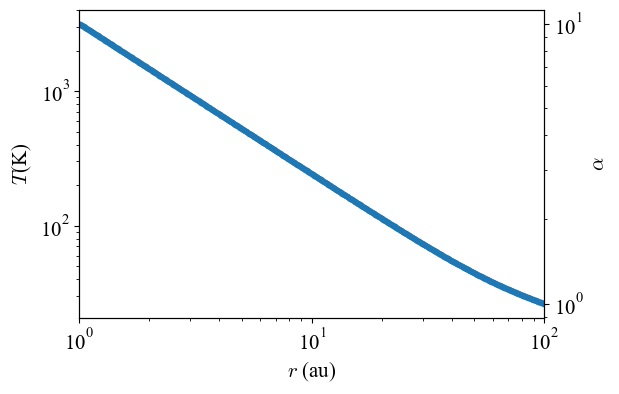

In [ ]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)
ax1 = ax.twinx()
rad = r[:,-1]/L_norm
ax.plot(rad, Tem[:,-1],'.')
# plt.plot(rad, T0*(rad/a0)**qvalue)
# ax1.plot(rad, nu_gas[:,-1] / ((rad/a0)**(-sigma_slope)), color = 'k')
ax1.set_yscale('log')
ax1.set_ylabel(r'$\alpha$')

ax.set_ylabel('$T$(K)')
ax.set_xlabel('$r$ (au)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1.0,100)

In [ ]:
nu_gas[:,-1] / ((rad/a0)**(-sigma_slope))

In [ ]:
# plt.plot(rad, exp(-Q_GI[:,-1]**2))

In [ ]:
plt.plot(rad, sum(rho0*dx2 ,axis = 1)*UNIT_DEN*UNIT_L*2.0)
plt.plot(rad, sigma_profile(rad))
plt.xlim(20,80)
plt.ylim(100,500)